# Análisis de ventas (notebook)
Notebook interactivo que reutiliza las funciones del proyecto `analisis_ventas` para:
- Cargar el CSV de ventas
- Calcular métricas por mes y por producto
- Generar un dashboard de gráficos

In [1]:
import pandas as pd

from analisis import (
    cargar_datos,
    preparar_fechas,
    ventas_totales_por_mes,
    producto_top_por_mes,
    producto_top_periodo,
    producto_mas_ingresos_periodo,
    producto_mas_ingresos_por_mes,
)
from graficos import graficar_dashboard

from IPython.display import Image

In [2]:
df = cargar_datos("ventas.csv")
df = preparar_fechas(df)
df.head()

,fecha,producto,cantidad,precio,mes
0,2025-01-02,A,3,10.0,2025-01-01
1,2025-01-05,B,1,20.0,2025-01-01
2,2025-01-10,C,2,15.0,2025-01-01
3,2025-01-15,A,5,10.0,2025-01-01
4,2025-01-20,D,1,25.0,2025-01-01


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   fecha     40 non-null     datetime64[us]
 1   producto  40 non-null     str           
 2   cantidad  40 non-null     int64         
 3   precio    40 non-null     float64       
 4   mes       40 non-null     datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(1), str(1)
memory usage: 1.7 KB


In [4]:
resumen_mensual = ventas_totales_por_mes(df)
top_mes_cantidad = producto_top_por_mes(df)
top_periodo_cantidad = producto_top_periodo(df)
top_periodo_ingresos = producto_mas_ingresos_periodo(df)
top_mes_ingresos = producto_mas_ingresos_por_mes(df)
resumen_mensual

,mes,cantidad_total,ingresos_totales
0,2025-01-01,16,187.0
1,2025-02-01,16,215.0
2,2025-03-01,17,341.0
3,2025-04-01,20,534.0
4,2025-05-01,25,272.0
5,2025-06-01,28,273.0


In [5]:
top_mes_cantidad

,mes,producto,cantidad_total,ingresos_totales
0,2025-01-01,A,8,80.0
5,2025-02-01,A,5,50.0
10,2025-03-01,A,6,60.0
17,2025-04-01,B,5,100.0
27,2025-05-01,G,8,40.0
33,2025-06-01,G,10,50.0


In [6]:
top_periodo_cantidad

,producto,cantidad_total,ingresos_totales
0,A,34,340.0


In [7]:
top_periodo_ingresos

,producto,cantidad_total,ingresos_totales
5,F,3,360.0


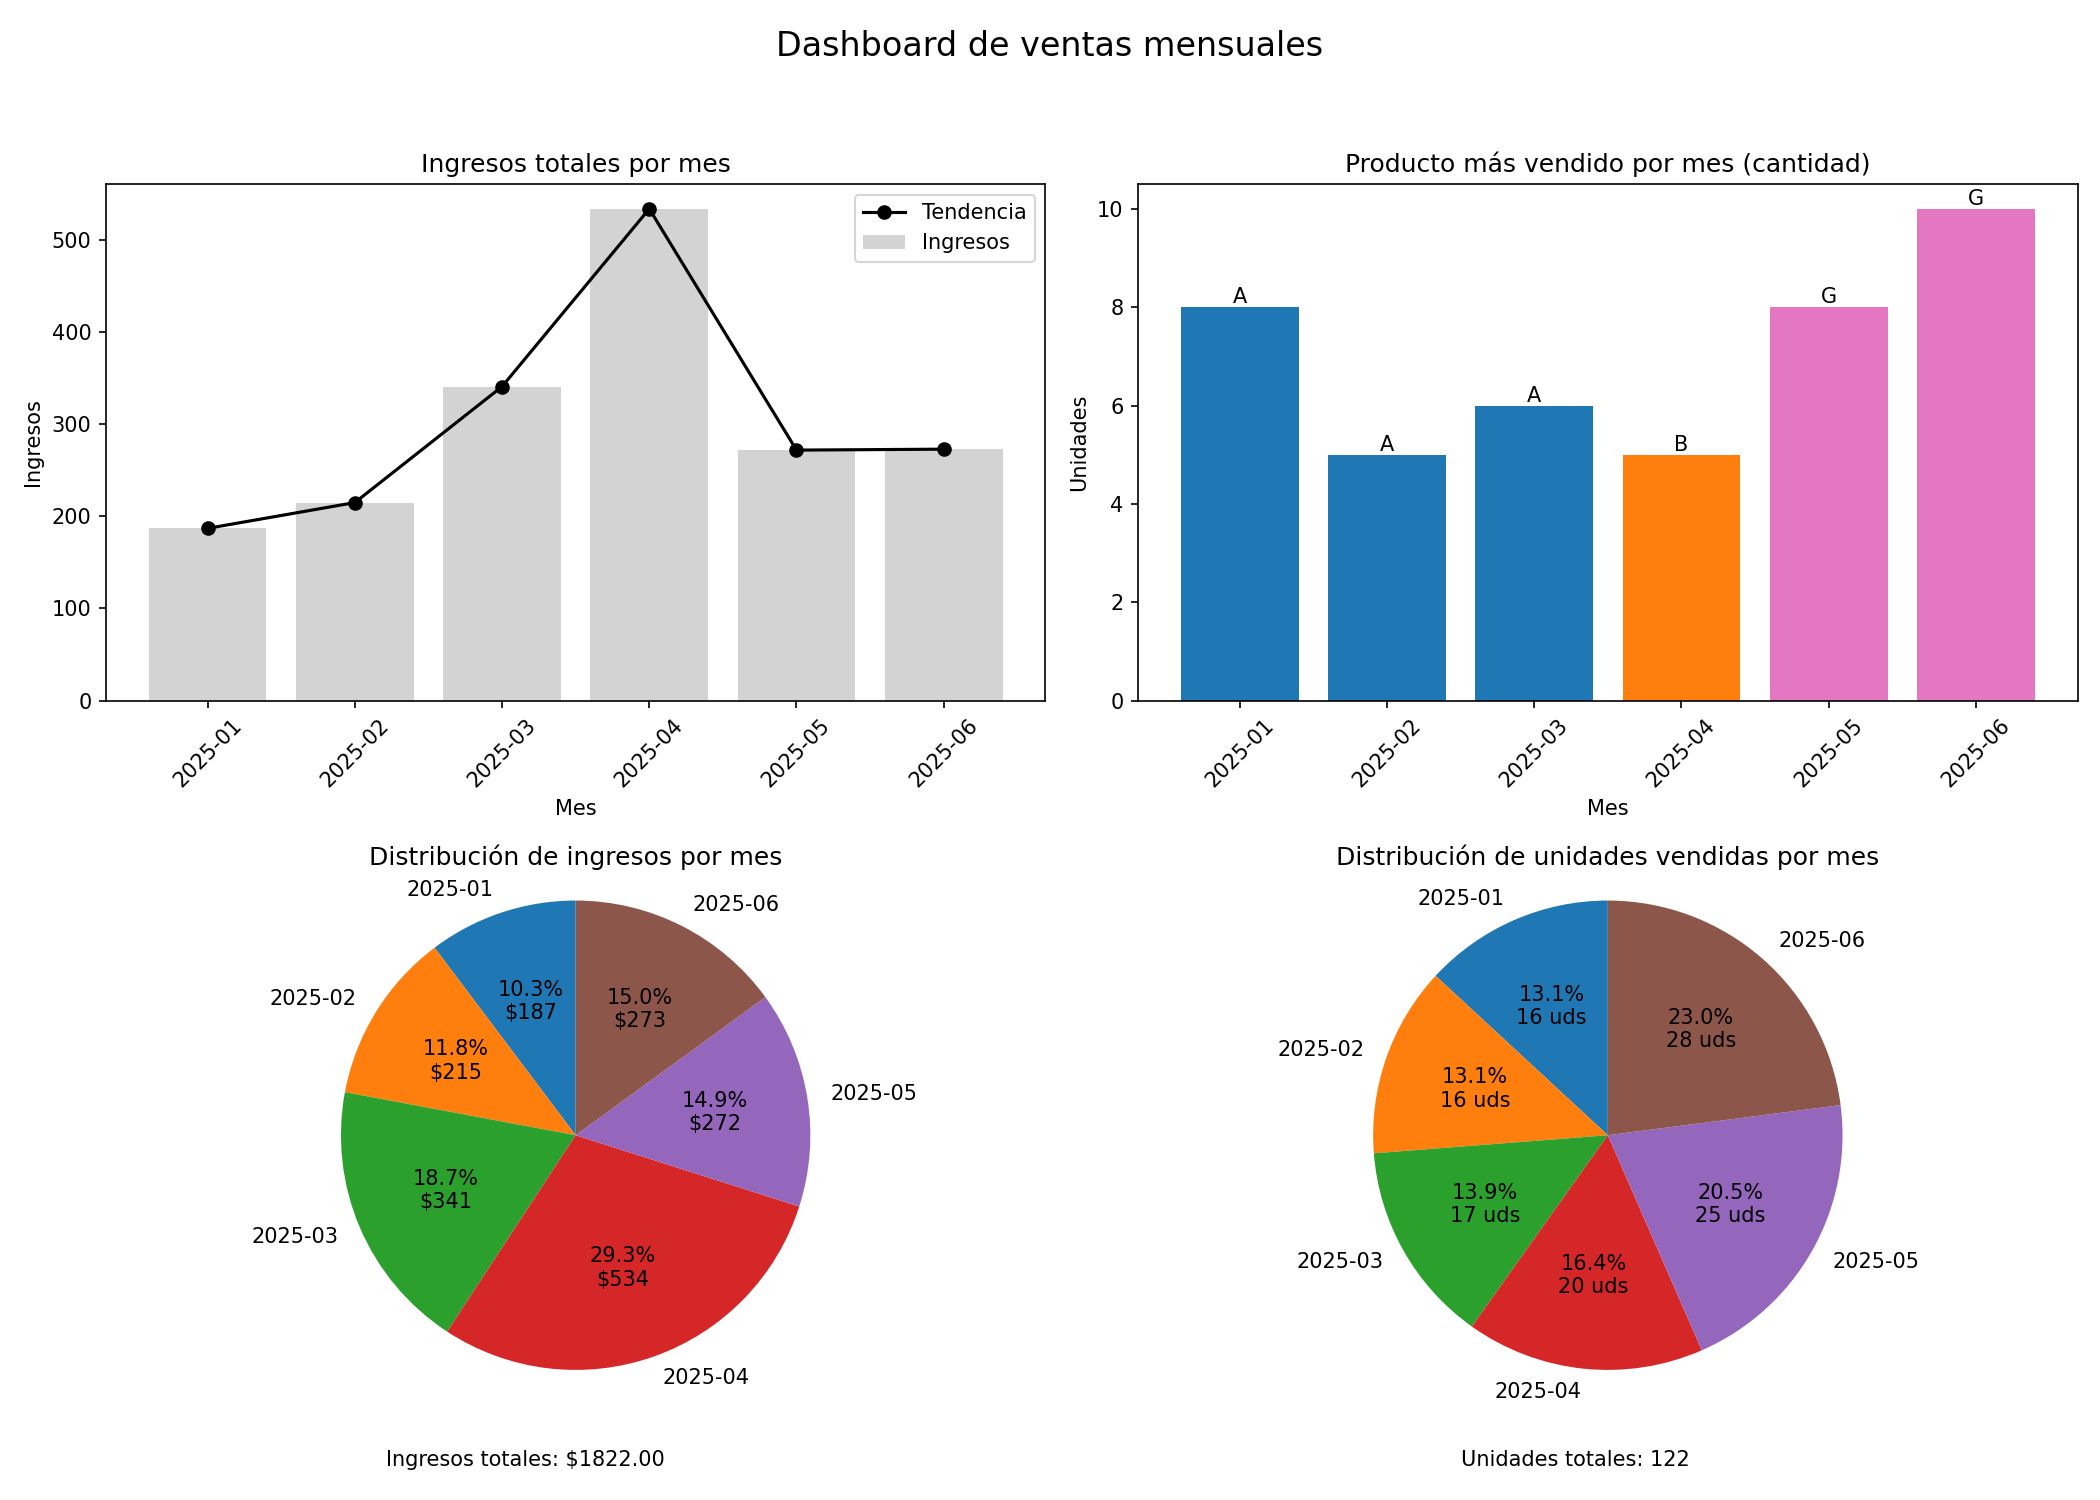

In [8]:
graficar_dashboard(
    resumen_mensual=resumen_mensual,
    top_mes_cantidad=top_mes_cantidad,
    top_mes_ingresos=top_mes_ingresos,
    ruta_png="dashboard_ventas_notebook.png",
)
Image("dashboard_ventas_notebook.png")

## Conclusiones
- El producto más vendido en el periodo es A, con 34 unidades vendidas en el periodo establecido.
- El producto que más ingresos genera es F, con 360€ en el periodo establecido.
- Los meses con mayor volumen de ingresos son Abril y Marzo, respectivamente.